In [1]:
import os
import torch
import numpy as np
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.transforms.functional as TF
import matplotlib.pyplot as plt
import random


In [2]:

class StackedGANData(Dataset):
    def __init__(self, root_dir):
        self.root_dir = root_dir
        # Filtering to ensure we only grab image files
        self.list_files = [f for f in os.listdir(self.root_dir) if f.endswith(('.jpg', '.png', '.jpeg'))]

    def __len__(self):
        return len(self.list_files)

    def __getitem__(self, index):
        img_file = self.list_files[index]
        img_path = os.path.join(self.root_dir, img_file)
        
        # Load image and convert to RGB
        image = Image.open(img_path).convert("RGB")
        width, height = image.size # Usually 512x256
        
        # Split the image
        # Edges2Shoes: Sketch on Left, Real on Right
        sketch = image.crop((0, 0, width//2, height))
        real = image.crop((width//2, 0, width, height))

        # --- Synchronized Augmentation ---
        # Pix2Pix works best with 'Random Jitter' (Resize to 286, then Random Crop to 256)
        # This prevents the model from "memorizing" exact pixel locations.
        
        # Resize
        resize = transforms.Resize(size=(286, 286))
        sketch = resize(sketch)
        real = resize(real)

        # Random Crop
        i, j, h, w = transforms.RandomCrop.get_params(sketch, output_size=(256, 256))
        sketch = TF.crop(sketch, i, j, h, w)
        real = TF.crop(real, i, j, h, w)

        # Random Horizontal Flip
        if random.random() > 0.5:
            sketch = TF.hflip(sketch)
            real = TF.hflip(real)

        # Transform to Tensor and Normalize to [-1, 1]
        transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
        ])

        return transform(sketch), transform(real)



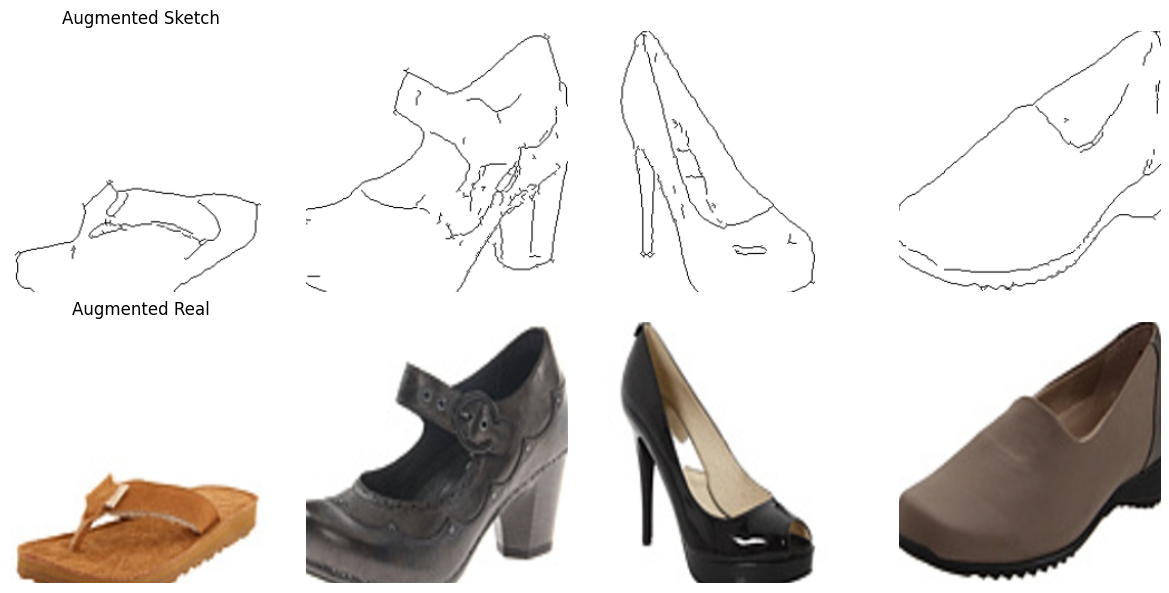

In [3]:
# --- Initialization ---
# Verify this path in your Kaggle 'Input' sidebar
TRAIN_DIR = "/kaggle/input/datasets/balraj98/edges2shoes-dataset/train" 

if not os.path.exists(TRAIN_DIR):
    print(f"⚠️ Warning: {TRAIN_DIR} not found. Check your dataset path!")

dataset = StackedGANData(root_dir=TRAIN_DIR)
train_loader = DataLoader(dataset, batch_size=8, shuffle=True, num_workers=2, pin_memory=True)

# --- Verification Step ---
def show_batch(loader):
    sketches, reals = next(iter(loader))
    plt.figure(figsize=(12, 6))
    for i in range(4):
        # Sketch
        plt.subplot(2, 4, i+1)
        plt.imshow(sketches[i].permute(1, 2, 0) * 0.5 + 0.5)
        plt.axis('off')
        if i == 0: plt.title("Augmented Sketch")
        
        # Real
        plt.subplot(2, 4, i+5)
        plt.imshow(reals[i].permute(1, 2, 0) * 0.5 + 0.5)
        plt.axis('off')
        if i == 0: plt.title("Augmented Real")
    plt.tight_layout()
    plt.show()

show_batch(train_loader)

In [4]:
import torch
import torch.nn as nn

class UNetBlock(nn.Module):
    def __init__(self, in_channels, out_channels, down=True, use_dropout=False):
        super(UNetBlock, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 4, 2, 1, bias=False, padding_mode="reflect")
            if down
            else nn.ConvTranspose2d(in_channels, out_channels, 4, 2, 1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True) if not down else nn.LeakyReLU(0.2, inplace=True),
        )
        self.use_dropout = use_dropout
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = self.conv(x)
        return self.dropout(x) if self.use_dropout else x


In [5]:

class Stage1Generator(nn.Module):
    def __init__(self, in_channels=3, features=64):
        super().__init__()
        # Encoder: 256 -> 128 -> 64 -> 32 -> 16 -> 8 -> 4 -> 2
        self.initial_down = nn.Sequential(
            nn.Conv2d(in_channels, features, 4, 2, 1, padding_mode="reflect"),
            nn.LeakyReLU(0.2),
        ) 
        
        self.down1 = UNetBlock(features, features * 2)      
        self.down2 = UNetBlock(features * 2, features * 4) 
        self.down3 = UNetBlock(features * 4, features * 8) 
        self.down4 = UNetBlock(features * 8, features * 8) 
        self.down5 = UNetBlock(features * 8, features * 8) 
        self.down6 = UNetBlock(features * 8, features * 8) 
        
        # Bottleneck: 2 -> 1
        self.bottleneck = nn.Sequential(
            nn.Conv2d(features * 8, features * 8, 4, 2, 1), 
            nn.ReLU(inplace=True)
        )

        # Decoder with Skip Connections: 1 -> 2 -> 4 -> 8 -> 16 -> 32 -> 64 -> 128
        self.up1 = UNetBlock(features * 8, features * 8, down=False, use_dropout=True)
        self.up2 = UNetBlock(features * 8 * 2, features * 8, down=False, use_dropout=True)
        self.up3 = UNetBlock(features * 8 * 2, features * 8, down=False, use_dropout=True)
        self.up4 = UNetBlock(features * 8 * 2, features * 8, down=False)
        self.up5 = UNetBlock(features * 8 * 2, features * 4, down=False)
        self.up6 = UNetBlock(features * 4 * 2, features * 2, down=False)
        self.up7 = UNetBlock(features * 2 * 2, features, down=False)
        
        # Final Layer: 128 -> 256
        self.final_up = nn.Sequential(
            nn.ConvTranspose2d(features * 2, in_channels, kernel_size=4, stride=2, padding=1),
            nn.Tanh(), 
        )

    def forward(self, x):
        # Encoder
        d1 = self.initial_down(x)
        d2 = self.down1(d1)
        d3 = self.down2(d2)
        d4 = self.down3(d3)
        d5 = self.down4(d4)
        d6 = self.down5(d5)
        d7 = self.down6(d6)
        bn = self.bottleneck(d7)

        # Decoder with Skip Connections (Concatenating encoder features)
        u1 = self.up1(bn)
        u2 = self.up2(torch.cat([u1, d7], 1))
        u3 = self.up3(torch.cat([u2, d6], 1))
        u4 = self.up4(torch.cat([u3, d5], 1))
        u5 = self.up5(torch.cat([u4, d4], 1))
        u6 = self.up6(torch.cat([u5, d3], 1))
        u7 = self.up7(torch.cat([u6, d2], 1))
        
        # Final cat with d1 before the last upsample
        return self.final_up(torch.cat([u7, d1], 1))


In [6]:

# Quick Validation
device = "cuda" if torch.cuda.is_available() else "cpu"
model_gen1 = Stage1Generator().to(device)
gen1 = model_gen1
print("Stage 1 Generator initialized with Skip Connections.")

Stage 1 Generator initialized with Skip Connections.


In [7]:
class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super(ResidualBlock, self).__init__()
        self.block = nn.Sequential(
            nn.Conv2d(channels, channels, kernel_size=3, padding=1, bias=False, padding_mode="reflect"),
            nn.BatchNorm2d(channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels, channels, kernel_size=3, padding=1, bias=False, padding_mode="reflect"),
            nn.BatchNorm2d(channels)
        )

    def forward(self, x):
        # The residual connection is key to preventing the "green noise"
        return x + self.block(x)


In [8]:
class Stage2Refiner(nn.Module):
    def __init__(self, in_channels=3, features=64, num_residuals=9): # Increased to 9 for better texture
        super().__init__()
        
        # Using a 7x7 kernel for the initial layer helps the model see a wider 
        # area of the coarse image to fix local artifacts.
        self.initial = nn.Sequential(
            nn.Conv2d(in_channels, features, kernel_size=7, stride=1, padding=3, padding_mode="reflect"),
            nn.BatchNorm2d(features),
            nn.ReLU(inplace=True)
        )
        
        # Residual blocks do the heavy lifting of sharpening the image
        self.res_blocks = nn.Sequential(
            *[ResidualBlock(features) for _ in range(num_residuals)]
        )
        
        # Final layer to bring it back to 3 channels
        self.final = nn.Sequential(
            nn.Conv2d(features, in_channels, kernel_size=7, stride=1, padding=3, padding_mode="reflect"),
            nn.Tanh() 
        )

    def forward(self, x):
        out = self.initial(x)
        out = self.res_blocks(out)
        return self.final(out)

# --- Validation ---
model_gen2 = Stage2Refiner().to(device)
gen2=model_gen2
print("Stage 2 Refiner initialized with Residual Blocks.")

Stage 2 Refiner initialized with Residual Blocks.


In [9]:
class DiscBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride):
        super(DiscBlock, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 4, stride, 1, bias=False, padding_mode="reflect"),
            nn.BatchNorm2d(out_channels),
            nn.LeakyReLU(0.2, inplace=True),
        )

    def forward(self, x):
        return self.conv(x)

class PatchGANDiscriminator(nn.Module):
    def __init__(self, in_channels=3, features=[64, 128, 256, 512]):
        super().__init__()
        # Initial layer: No BatchNorm as per original Pix2Pix paper
        self.initial = nn.Sequential(
            nn.Conv2d(in_channels * 2, features[0], kernel_size=4, stride=2, padding=1, padding_mode="reflect"),
            nn.LeakyReLU(0.2, inplace=True),
        )

        layers = []
        in_chs = features[0]
        # Intermediate layers
        for feature in features[1:]:
            # The original architecture uses stride 2 until the last feature map
            # then uses stride 1 to keep the final grid size useful.
            stride = 1 if feature == features[-1] else 2
            layers.append(DiscBlock(in_chs, feature, stride=stride))
            in_chs = feature

        # Final prediction layer: Produces the 30x30 (approx) grid of real/fake scores
        layers.append(
            nn.Conv2d(in_chs, 1, kernel_size=4, stride=1, padding=1, padding_mode="reflect"),
        )

        self.model = nn.Sequential(*layers)

    def forward(self, sketch, product):
        # Concatenate along the channel dimension (3+3=6)
        x = torch.cat([sketch, product], dim=1)
        x = self.initial(x)
        return self.model(x)


In [10]:

# --- Validation ---
model_disc = PatchGANDiscriminator().to(device)
disc = model_disc
print(f"Discriminator ready. Input: 6 channels, Output: Patch grid.")

Discriminator ready. Input: 6 channels, Output: Patch grid.


In [11]:
from torchvision import models

class VGGPerceptualLoss(nn.Module):
    def __init__(self):
        super(VGGPerceptualLoss, self).__init__()
        # Using VGG19 features pre-trained on ImageNet
        vgg = models.vgg19(weights=models.VGG19_Weights.IMAGENET1K_V1).features
        self.slice1 = nn.Sequential(*vgg[:4])   # Captures basic edges
        self.slice2 = nn.Sequential(*vgg[4:9])  # Captures textures
        self.slice3 = nn.Sequential(*vgg[9:18]) # Captures structural parts
        
        # Freeze weights so we don't train VGG itself
        for param in self.parameters():
            param.requires_grad = False
            
    def forward(self, x, y):
        # x and y are in range [-1, 1]. VGG likes [0, 1] with ImageNet normalization.
        # We'll do a simple shift here to keep it efficient.
        x = (x + 1) / 2
        y = (y + 1) / 2
        
        h1_x, h1_y = self.slice1(x), self.slice1(y)
        h2_x, h2_y = self.slice2(h1_x), self.slice2(h1_y)
        h3_x, h3_y = self.slice3(h2_x), self.slice3(h2_y)
        
        # Combining L1 loss of feature maps
        loss = nn.functional.l1_loss(h1_x, h1_y) + \
               nn.functional.l1_loss(h2_x, h2_y) + \
               nn.functional.l1_loss(h3_x, h3_y)
        return loss


In [12]:
import torch.optim as optim

# Standard setup
device = "cuda" if torch.cuda.is_available() else "cpu"


# Standard Criteria
BCE = nn.BCEWithLogitsLoss()
L1_LOSS = nn.L1Loss()
PERCEPTUAL_LOSS = VGGPerceptualLoss().to(device)


Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:02<00:00, 196MB/s]


In [13]:
# Replace the paths with the actual location of your saved files
gen1.load_state_dict(torch.load("/kaggle/input/datasets/vidwathkumar0054/gen1-gen2-10epoch/gen1_epoch10.pth"))
gen2.load_state_dict(torch.load("/kaggle/input/datasets/vidwathkumar0054/gen1-gen2-10epoch/gen2_epoch10.pth"))

print("✅ Successfully loaded Epoch 10 weights. Ready for polishing.")

✅ Successfully loaded Epoch 10 weights. Ready for polishing.


In [14]:
# --- Fine-Tuning Constants ---
NEW_LR = 2e-5      # 10x smaller than before
LAMBDA_L1 = 100    # Keep structure strong
LAMBDA_PERC = 30   # INCREASED from 10 to fix colors/materials

opt_gen = optim.Adam(list(gen1.parameters()) + list(gen2.parameters()), lr=NEW_LR, betas=(0.5, 0.999))
opt_disc = optim.Adam(disc.parameters(), lr=NEW_LR, betas=(0.5, 0.999))

scaler = torch.amp.GradScaler('cuda')

In [15]:
def train_step_polished(sketch, real, gen1, gen2, disc, opt_gen, opt_disc):
    with torch.amp.autocast('cuda'):
        fake_coarse = gen1(sketch)
        fake_refined = gen2(fake_coarse)
        
        # Discriminator Update
        disc_real = disc(sketch, real)
        disc_fake = disc(sketch, fake_refined.detach())
        loss_d = (BCE(disc_real, torch.ones_like(disc_real)) + 
                  BCE(disc_fake, torch.zeros_like(disc_fake))) / 2

    opt_disc.zero_grad()
    scaler.scale(loss_d).backward()
    scaler.step(opt_disc)
    scaler.update()

    with torch.amp.autocast('cuda'):
        # Generator Update
        disc_fake = disc(sketch, fake_refined)
        loss_adv = BCE(disc_fake, torch.ones_like(disc_fake))
        
        # We use the higher LAMBDA_PERC here
        loss_l1_coarse = L1_LOSS(fake_coarse, real) * 10
        loss_l1_refined = L1_LOSS(fake_refined, real) * 100
        loss_vgg = PERCEPTUAL_LOSS(fake_refined, real) * LAMBDA_PERC
        
        loss_g = loss_adv + loss_l1_refined + loss_l1_coarse + loss_vgg

    opt_gen.zero_grad()
    scaler.scale(loss_g).backward()
    scaler.step(opt_gen)
    scaler.update()
    
    return loss_d, loss_g

# --- Run for 5 Polish Epochs ---
FINE_TUNE_EPOCHS = 5
for epoch in range(1, FINE_TUNE_EPOCHS + 1):
    gen1.train(); gen2.train(); disc.train()
    for idx, (sketch, real) in enumerate(train_loader):
        sketch, real = sketch.to(device), real.to(device)
        ld, lg = train_step_polished(sketch, real, gen1, gen2, disc, opt_gen, opt_disc)
        
        if idx % 100 == 0:
            print(f"Polish Epoch [{epoch}/{FINE_TUNE_EPOCHS}] | Loss D: {ld:.4f} Loss G: {lg:.4f}")

  

Polish Epoch [1/5] | Loss D: 0.7256 Loss G: 41.3897
Polish Epoch [1/5] | Loss D: 0.6700 Loss G: 21.6750
Polish Epoch [1/5] | Loss D: 0.5552 Loss G: 35.5586
Polish Epoch [1/5] | Loss D: 0.5947 Loss G: 21.9786
Polish Epoch [1/5] | Loss D: 0.6226 Loss G: 32.1708
Polish Epoch [1/5] | Loss D: 0.5501 Loss G: 29.8018
Polish Epoch [1/5] | Loss D: 0.5006 Loss G: 24.6406
Polish Epoch [1/5] | Loss D: 0.7354 Loss G: 27.0651
Polish Epoch [1/5] | Loss D: 0.5596 Loss G: 26.0967
Polish Epoch [1/5] | Loss D: 0.4488 Loss G: 33.3532
Polish Epoch [1/5] | Loss D: 0.9995 Loss G: 24.6960
Polish Epoch [1/5] | Loss D: 0.5720 Loss G: 32.9879
Polish Epoch [1/5] | Loss D: 0.7671 Loss G: 29.0226
Polish Epoch [1/5] | Loss D: 0.3150 Loss G: 33.4823
Polish Epoch [1/5] | Loss D: 0.3859 Loss G: 26.5437
Polish Epoch [1/5] | Loss D: 0.4807 Loss G: 32.5825
Polish Epoch [1/5] | Loss D: 0.2085 Loss G: 37.7480
Polish Epoch [1/5] | Loss D: 0.4048 Loss G: 29.3147
Polish Epoch [1/5] | Loss D: 0.4626 Loss G: 38.5793
Polish Epoch

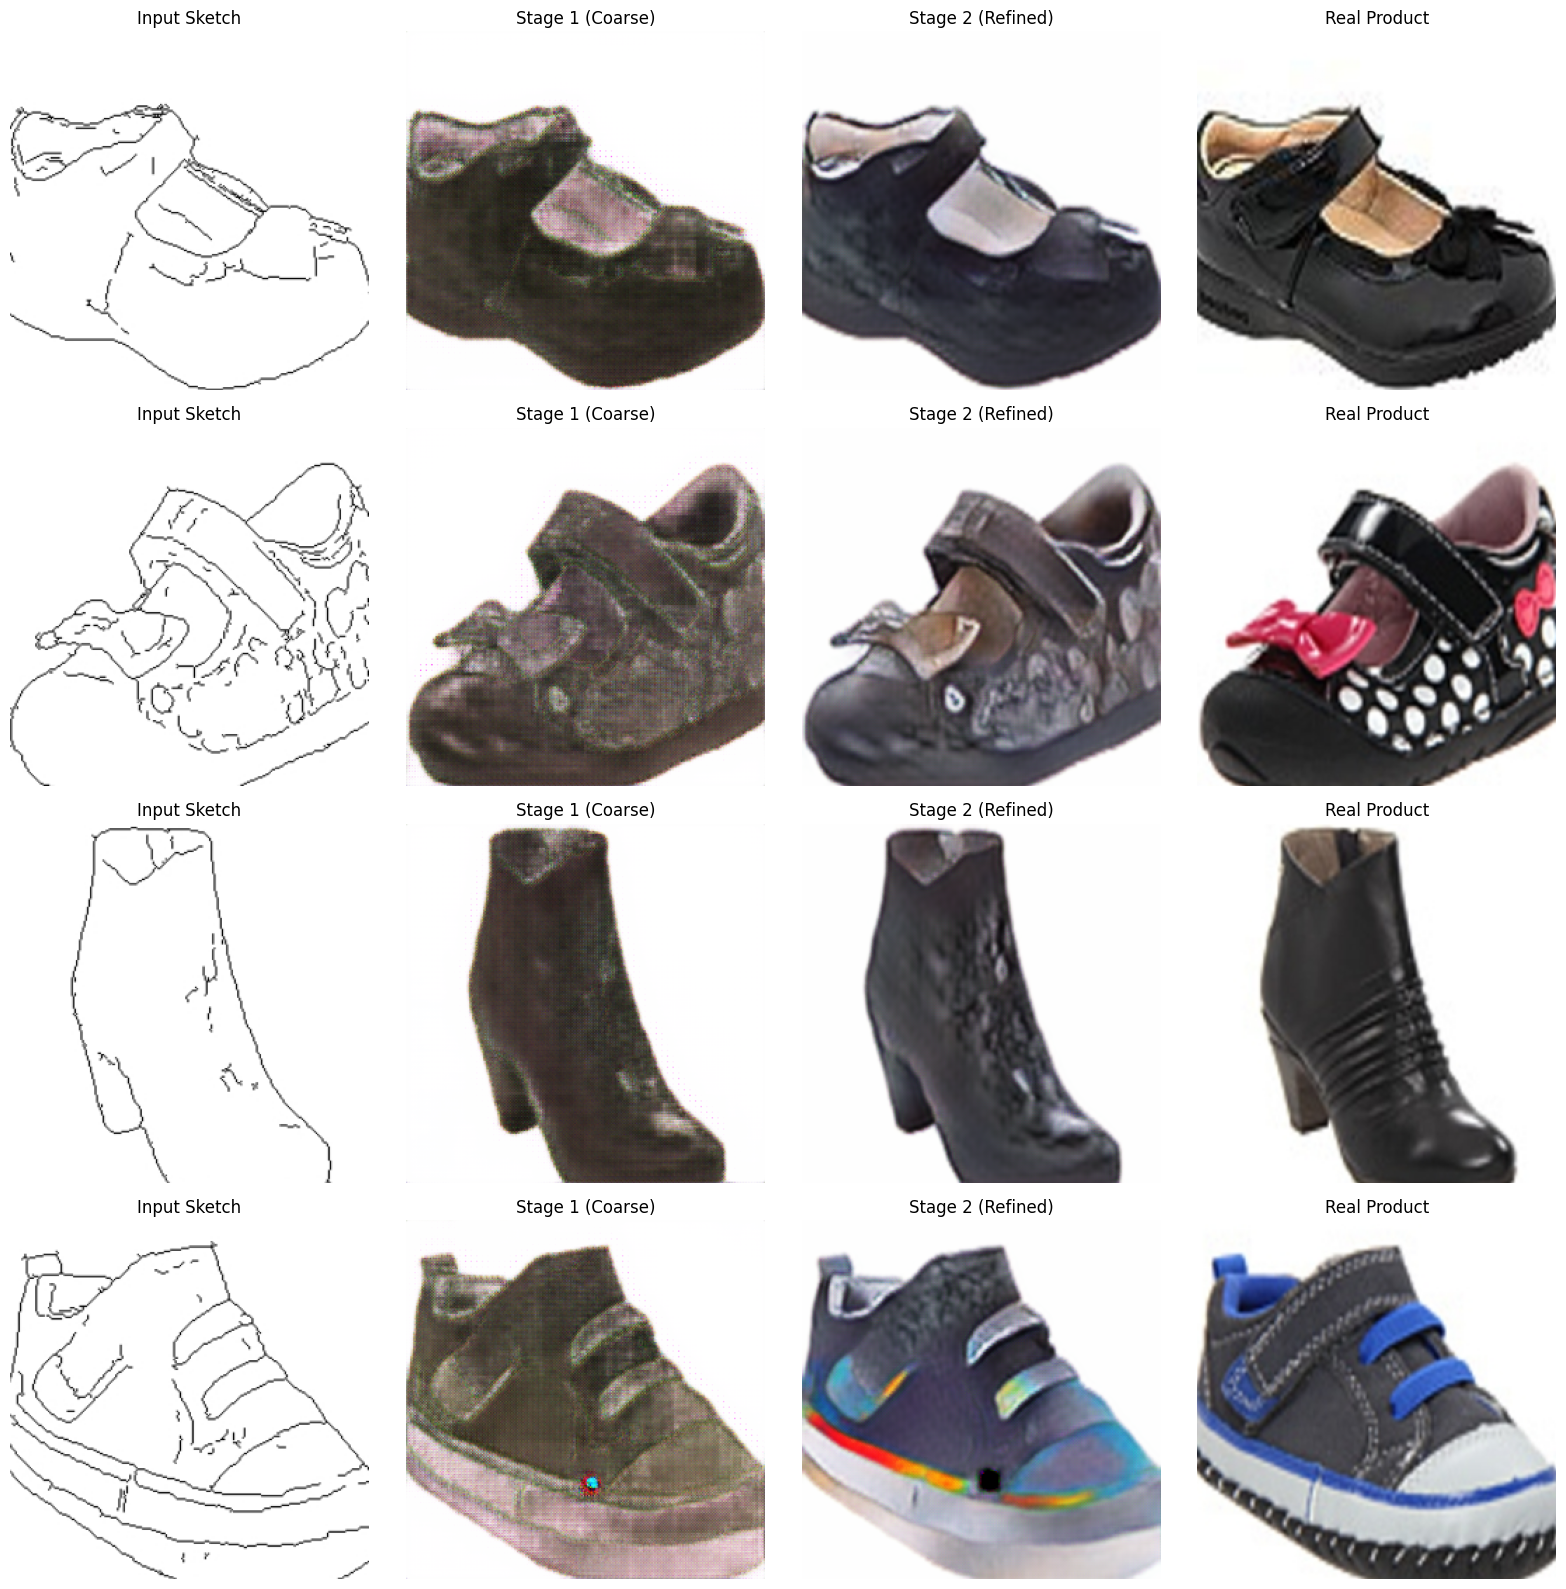

Pipeline visualization complete and both models saved!


In [16]:
import matplotlib.pyplot as plt

def visualize_stacked_results(g1, g2, loader, device, num_samples=4):
    g1.eval()
    g2.eval()
    sketch, real = next(iter(loader))
    sketch, real = sketch.to(device), real.to(device)
    
    with torch.no_grad():
        coarse = g1(sketch)
        refined = g2(coarse)
    
    # Denormalize [-1, 1] -> [0, 1]
    imgs = [sketch, coarse, refined, real]
    imgs = [img * 0.5 + 0.5 for img in imgs]

    titles = ["Input Sketch", "Stage 1 (Coarse)", "Stage 2 (Refined)", "Real Product"]
    
    plt.figure(figsize=(16, num_samples * 4))
    for i in range(num_samples):
        for j in range(4):
            plt.subplot(num_samples, 4, i*4 + j + 1)
            plt.imshow(imgs[j][i].permute(1, 2, 0).cpu().numpy())
            plt.title(titles[j])
            plt.axis("off")
    
    plt.tight_layout()
    plt.show()

# 1. Visualize the pipeline
visualize_stacked_results(gen1, gen2, train_loader, device)

# 2. Save both models
# These will appear in the /kaggle/working/ directory
torch.save(gen1.state_dict(), "gen1_final_polished.pth")
torch.save(gen2.state_dict(), "gen2_final_polished.pth")

print("Pipeline visualization complete and both models saved!")